In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import pandas as pd
import seaborn

from fbio.dataframe import RegionDataFrame
from fbio.fragments_h5 import FragmentsH5

from ravel.fragment_array import RegionFragmentArray, FragmentMatrix, Region, merge_fragment_arrays
from ravel.bio.frag.fragment_matrix import merge_fragment_matrices

In [3]:
pd.read_csv("/scratch/karius/Merged_meta_data_CD_UC_foundation.csv")

,LibraryID,SeqRun,SampleID,library_name,Index,SNM,IDSpike,BioMaterial,IBD_ID,DEIDENTIFIED_MASTER_PATIENT_ID,...,Chemotherapeutic,Corticosteroids,Probiotic,Anti_diarrheal,NSAID,Antibiotic,Cluster,SEX_x,Aliquote_ID,SEX_y
0,RD-56150-Lib1,NC-14151,RD-56150,RD-56150-Lib1,NEB_E6440_A01,"SNM.v3, SNM.v4","136 (v3), 3001 (v4)",plasma,9032553,9032553.0,...,1.0,1.0,1.0,1.0,0.0,0.0,Patient Group 1,NaN,NaN,NaN
1,RD-56153-Lib1,NC-14151,RD-56153,RD-56153-Lib1,NEB_E6440_D01,"SNM.v3, SNM.v4","136 (v3), 3002 (v4)",plasma,9032562,9032562.0,...,1.0,1.0,0.0,0.0,1.0,1.0,Patient Group 2,NaN,NaN,NaN
2,RD-56154-Lib1,NC-14151,RD-56154,RD-56154-Lib1,NEB_E6440_E01,"SNM.v3, SNM.v4","136 (v3), 3003 (v4)",plasma,9032139,9032139.0,...,1.0,0.0,0.0,0.0,0.0,0.0,Patient Group 4,NaN,NaN,NaN
3,RD-56155-Lib1,NC-14151,RD-56155,RD-56155-Lib1,NEB_E6440_F01,"SNM.v3, SNM.v4","136 (v3), 3004 (v4)",plasma,9032171,9032171.0,...,0.0,0.0,0.0,0.0,0.0,0.0,Patient Group 3,NaN,NaN,NaN
4,RD-56156-Lib1,NC-14151,RD-56156,RD-56156-Lib1,NEB_E6440_G01,"SNM.v3, SNM.v4","136 (v3), 3066 (v4)",plasma,12078136,12078136.0,...,0.0,1.0,1.0,1.0,0.0,0.0,Patient Group 1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,RD-36399-Lib1,NC-13295,RD-36399,RD-36399-Lib1,NEB_E6440_B01,"SNM.v3, SNM.v4","ID_136 (v3), 3109 (v4)",PPT plasma,[BDP_005],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
362,RD-36400-Lib1,NC-13295,RD-36400,RD-36400-Lib1,NEB_E6440_C01,"SNM.v3, SNM.v4","ID_136 (v3), 3110 (v4)",PPT plasma,[BDP_005],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,RD-36401-Lib1,NC-13295,RD-36401,RD-36401-Lib1,NEB_E6440_D01,"SNM.v3, SNM.v4","ID_136 (v3), 3111 (v4)",PPT plasma,[BDP_005],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,RD-36402-Lib1,NC-13295,RD-36402,RD-36402-Lib1,NEB_E6440_E01,"SNM.v3, SNM.v4","ID_136 (v3), 3112 (v4)",PPT plasma,[BDP_005],NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import glob

def load_sample_metadata_df():    
    sample_ids_to_samples = {}
    for fname in glob.glob("/scratch/karius/*.fragments.h5"):
        sample_id = fname.split("/")[3].split('.')[1].split('_')[0][:-5]
        sample_ids_to_samples[sample_id] = fname

    assert 1 == pd.read_csv("/scratch/karius/Merged_meta_data_CD_UC_foundation.csv")["SampleID"].value_counts().max()
    metadata = pd.read_csv("/scratch/karius/Merged_meta_data_CD_UC_foundation.csv")
    metadata = metadata.query("SampleID in @sample_ids_to_samples.keys()").set_index("SampleID")[['DIAGNOSIS', 'ENDO_CATEGORY', 'Cluster', 'SITE_NUMBER']]
    return metadata, sample_ids_to_samples

In [5]:
metadata, sample_ids_to_samples = load_sample_metadata_df()

In [6]:
import seaborn as sns
import numpy as np

def plot_and_load_ref_fl_dist():
    max_frag_len = 512
    sns.set(rc={'figure.figsize':(20, 8)})
    columns = {}
    for sample_id, fname in sample_ids_to_samples.items():
        cnts = FragmentsH5(fname).fragment_length_counts[:max_frag_len]
        # normalize to library depth
        cnts = cnts/cnts.sum()
        columns[sample_id] = cnts

    fl_df = pd.DataFrame(columns)
    fl_df = fl_df.set_index(fl_df.index+1)

    ref_fl_dist = fl_df.mean(axis=1)
    ref_fl_dist = ref_fl_dist/ref_fl_dist.sum()

    color_mapping = dict(Severe='red', Moderate='orange', Mild='yellow', Remission='green')
    colors = [color_mapping[x] for x in metadata.loc[fl_df.columns].ENDO_CATEGORY.tolist()]

    fl_df.loc[:, 'Reference'] = ref_fl_dist
    colors.append('black')

    fl_df.plot(color=colors)

    return ref_fl_dist, color_mapping

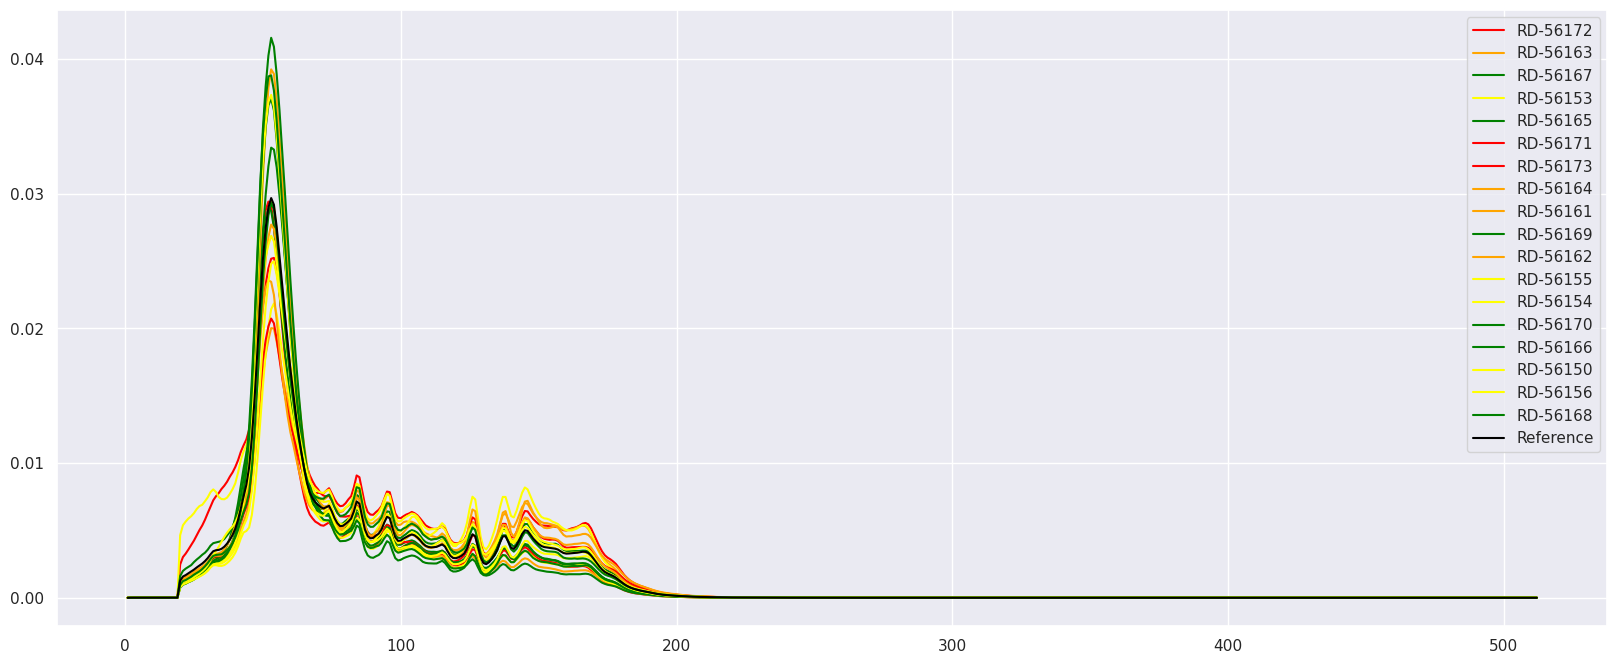

In [7]:
ref_fl_dist, color_mapping = plot_and_load_ref_fl_dist()

In [8]:
# frag_h5 = FragmentsH5("/scratch/karius/finished.fragments.h5") # "/scratch/test_samples/SEQRUN48_LIBRARY577.fragments.h5")
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = metadata.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')

from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

def StrandSplitCoverageTrack(fa, *args, **kwargs):
    p1 = CoverageTrack(fa.subset_by_fragment_strand('+'), *args, color='black', **kwargs)
    p1.name = p1.name + ' - Fwd Strand'
    p2 = CoverageTrack(fa.subset_by_fragment_strand('-'), *args, color='green', **kwargs)
    p2.name = p2.name + ' - Rev Strand'
    return p1 + p2

def make_tracks(fa, extra_tracks=False, include_cutsites=False, include_vplot=False):
    region_size = fa.shape[1]

    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))
    if include_cutsites:
        tracks.append(
            CoverageTrack(fa, fa.plot_region, coverage_type='left_endpoint', n_boot_coverage=0, fraction=None, smooth_window=5, 
                          vlines=[VLine(x=region_size//2-20)], 
                          name='left endpoint') 
            + CoverageTrack(fa, fa.plot_region, coverage_type='right_endpoint', n_boot_coverage=0, fraction=None, smooth_window=5, 
                            vlines=[VLine(x=region_size//2+20)], 
                            name='right endpoint'))
    if extra_tracks:
        tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=(20, 40), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='Very Small Peak (20 - 40)'))
        tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=(40, 60), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='50 BP Peak (40 - 60)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=(60, 100), smooth_window=200, ylim=(0, None),
                                vlines=[VLine(x=region_size//2)], 
                                name='sub-nucleosome (60 - 100)'))
    tracks.append(StrandSplitCoverageTrack(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=(110, 500), smooth_window=500, ylim=(0, None),
                                #vlines=[VLine(x=region_size//2+first_nuc+x*offset) for x in range(8)] + [VLine(x=region_size//2-first_nuc-x*offset) for x in range(8)], 
                                name='nucleosome (> 110)'))
    return tracks

def fa_from_rdf(_rdf, frag_h5, region_size, downsample_size=None, fl_normalize=True):
    max_frag_len = 512
    regions = list(_rdf.resize_regions(region_size, discard_invalid_resizes=True).iter_regions())
    fas = [RegionFragmentArray.from_fragments_h5(frag_h5, r, include_fragment_strand=True, flip_data_to_match_region_strand=True, min_mapq=10).drop_duplicate_fragments() for r in regions]
    fa = merge_fragment_arrays(fas) # .fragment_matrix

    # calculate the fl acceptance probs
    if fl_normalize:
        fl_cnts = frag_h5.fragment_length_counts[:max_frag_len].clip(1)
        norm_fl_cnts = fl_cnts / fl_cnts.sum()
        scaling_factor = (ref_fl_dist/norm_fl_cnts).max()
        sample_acceptance_prbs = ref_fl_dist/(scaling_factor*norm_fl_cnts)
        fa = fa.downsampled_frag_lens(sample_acceptance_prbs.round(6))

    if downsample_size is not None:
        fa = fa.downsampled(downsample_size)
    return fa, fas

def fa_from_rdf_and_severity(severity, _rdf, region_size, downsample_size=None, fl_normalize=True, max_num_samples=3):
    fas = []
    selected_metadata = metadata
    if severity != 'ALL':
        assert severity in severities
        selected_metadata = metadata.query(f"ENDO_CATEGORY == '{severity}'")
    selected_metadata = selected_metadata.query("Cluster in @patient_groups")
    if max_num_samples < selected_metadata.shape[0]:
        selected_metadata.sample(n=max_num_samples)
    for sample_id in selected_metadata.index.tolist():
        frag_h5 = FragmentsH5(sample_ids_to_samples[sample_id])
        fa, _ = fa_from_rdf(_rdf, frag_h5, region_size=region_size, downsample_size=downsample_size, fl_normalize=fl_normalize)
        fas.append(fa)
    return merge_fragment_arrays(fas)

# CTCF Site Selection

In [9]:
def build_ctcf_binding_sites():
    ### load and merge all of the binding sites #######################################################################
    base_dir = "/scratch/ctcf_analysis/CTCF/cell_type_merged"
    index_cols = ['contig', 'start', 'stop', 'strand']
    dfs = []
    for fname in os.listdir(base_dir):
        # extract the biosample type from the filename
        cell_type = fname.split('.')[1]
        # load the data into a region dataframe
        df = RegionDataFrame(pd.read_table(os.path.join(base_dir, fname)), ref='hg38')
        # subset the dataframe by the binding site locations
        df = df[['contig', 'start', 'stop', 'strand', 'tf_top_score']].set_index(index_cols)
        # rename the score column to the biosample_type
        df = df.rename(columns={'tf_top_score': cell_type})
        df = df.sort_values(df.columns[0], ascending=False).head(20000).sort_index()
        dfs.append(df)

    # merge everything
    df = dfs[0]
    for i in range(1, len(dfs)): 
        df = df.join(dfs[i], how='outer')
        
    # binarize based upon peak presence
    df = pd.DataFrame(df.fillna(0).sort_index())
    df = (df > 1e-6).astype(int)
    
    # neutrophils look weird
    df = df.drop(columns='neutrophil')
    
    ### Build all of the masks ########################################################################################
    # we're excluding one blood and one neural so that the counts remain the same
    neural_columns = ['neural_progenitor_cell', 'neural_cell', 'dorsolateral_prefrontal_cortex'] # 'neural_crest_cell', 
    colon_columns = ['stomach', 'transverse_colon', 'sigmoid_colon']
    blood_columns = ['natural_killer_cell', 'B_cell', 'CD14-positive_monocyte'] # , 'CD8-positive,_alpha-beta_T_cell'
    all_columns = neural_columns + colon_columns + blood_columns

    all_bnd_mask = (df.sum(axis=1) == df.shape[1])


    all_neural_bnd_mask = (df.loc[:, neural_columns].sum(axis=1) >= len(neural_columns))
    no_non_neural_bnd_mask = (df.loc[:, colon_columns + blood_columns].sum(axis=1) <= 2)
    only_neural_mask = all_neural_bnd_mask&no_non_neural_bnd_mask

    all_colon_bnd_mask = (df.loc[:, colon_columns].sum(axis=1) >= len(colon_columns))
    no_non_colon_bnd_mask = (df.loc[:, neural_columns + blood_columns].sum(axis=1) <= 2)
    only_colon_mask = all_colon_bnd_mask&no_non_colon_bnd_mask

    all_blood_bnd_mask = (df.loc[:, blood_columns].sum(axis=1) >= len(blood_columns))
    no_non_blood_bnd_mask = (df.loc[:, neural_columns + colon_columns].sum(axis=1) <= 2)
    only_blood_mask = all_blood_bnd_mask&no_non_blood_bnd_mask

    assert all_bnd_mask.sum() + only_neural_mask.sum() + only_colon_mask.sum() + only_blood_mask.sum() == (all_bnd_mask | only_neural_mask | only_colon_mask | only_blood_mask).sum()
    
    # set the class column, and drop all of the binary labels
    df.loc[all_bnd_mask, 'cell_type'] = 'all'
    df.loc[only_neural_mask, 'cell_type'] = 'neural'
    df.loc[only_colon_mask, 'cell_type'] = 'colon'
    df.loc[only_blood_mask, 'cell_type'] = 'blood'
    df = df[['cell_type']].dropna()

    return RegionDataFrame(df.reset_index(), ref='hg38')

## Region Filtering

In [10]:
import tqdm
from scipy.stats.mstats import trimmed_std  

def make_counts_and_region_stats(rdf, sample_ids_to_samples):
    counts = {}
    for sample_id in tqdm.tqdm(sample_ids_to_samples.keys()):
        fa, fas = fa_from_rdf(rdf, FragmentsH5(sample_ids_to_samples[sample_id]), region_size=4096*8, downsample_size=None, fl_normalize=False)
        counts[sample_id] = [fa.n_frags for fa in fas]
    counts = pd.DataFrame(counts)
    counts = counts.set_index(rdf.set_index(['contig', 'start', 'stop', 'strand']).index)

    means = counts.median().rename('mean_fragment_counts')
    stds = counts.apply(lambda x: trimmed_std(x, (0.05, 0.05))).rename('std_fragment_counts')
    mins = (means - 3*stds).rename('min_fragments')
    maxs = (means + 3*stds).rename('max_fragments')

    fragment_stats = pd.DataFrame([means, stds, mins, maxs]).T
    
    regions_mask = ((counts >= fragment_stats.min_fragments) & (counts <= fragment_stats.max_fragments)).all(axis=1)
    filtered_rdf = rdf.loc[regions_mask.values, :]

    return filtered_rdf, counts, fragment_stats

# CTCF Analysis

In [13]:
# find counts for all of the regions
ctcf_rdf = build_ctcf_binding_sites()
filtered_ctcf_rdf, ctcf_region_counts, fragment_stats = make_counts_and_region_stats(ctcf_rdf.sample(100), sample_ids_to_samples)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18/18 [00:05<00:00,  3.19it/s]


In [14]:
# calculate summary statistics across all of the samples
metadata.join(fragment_stats)

,DIAGNOSIS,ENDO_CATEGORY,Cluster,SITE_NUMBER,mean_fragment_counts,std_fragment_counts,min_fragments,max_fragments
SampleID,,,,,,,,
RD-56150,Ulcerative Colitis,Mild,Patient Group 1,Site_13,520.5,38.114579,406.156264,634.843736
RD-56153,Ulcerative Colitis,Mild,Patient Group 2,Site_13,884.0,55.662315,717.013054,1050.986946
RD-56154,Ulcerative Colitis,Mild,Patient Group 4,Site_13,772.5,64.949743,577.650771,967.349229
RD-56155,Ulcerative Colitis,Mild,Patient Group 3,Site_13,1076.0,87.911452,812.265645,1339.734355
RD-56156,Ulcerative Colitis,Mild,Patient Group 1,Site_13,861.5,79.240578,623.778267,1099.221733
RD-56161,Ulcerative Colitis,Moderate,Patient Group 1,Site_13,774.5,79.322954,536.531139,1012.468861
RD-56162,Ulcerative Colitis,Moderate,Patient Group 3,Site_13,552.0,41.994928,426.015217,677.984783
RD-56163,Ulcerative Colitis,Moderate,Patient Group 3,Site_13,1617.0,101.282075,1313.153774,1920.846226
RD-56164,Ulcerative Colitis,Moderate,Patient Group 2,Site_13,915.5,68.295933,710.612201,1120.387799


In [15]:
ctcf_rdf['cell_type'].value_counts()

all       7718
neural     720
blood      550
colon      279
Name: cell_type, dtype: int64

In [16]:
filtered_ctcf_rdf['cell_type'].value_counts()

all       73
blood      7
neural     4
colon      2
Name: cell_type, dtype: int64

In [17]:
fa = fa_from_rdf_and_severity('ALL', filtered_ctcf_rdf.query("cell_type == 'all'"), region_size=4096*4, fl_normalize=True, max_num_samples=12)

WARNING	2024-02-08 05:23:43,404	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:43,612	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:43,842	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:44,081	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:44,299	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:44,529	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:44,927	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:45,133	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:45,409	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:45,640	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:45,844	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:46,050	Discarded 0 of 73 regions due to invalid resize.
WARNING	2024-02-08 05:23:46,

(<Figure size 2500x1400 with 8 Axes>,
 [<AxesSubplot:title={'center':' 18930 frags'}>,
  <AxesSubplot:title={'center':'left endpoint right endpoint'}>,
  <AxesSubplot:title={'center':'Very Small Peak (20 - 40) - Fwd Strand Very Small Peak (20 - 40) - Rev Strand'}>,
  <AxesSubplot:title={'center':'50 BP Peak (40 - 60) - Fwd Strand 50 BP Peak (40 - 60) - Rev Strand'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (60 - 100) - Fwd Strand sub-nucleosome (60 - 100) - Rev Strand'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110) - Fwd Strand nucleosome (> 110) - Rev Strand'}, xlabel='NA'>])

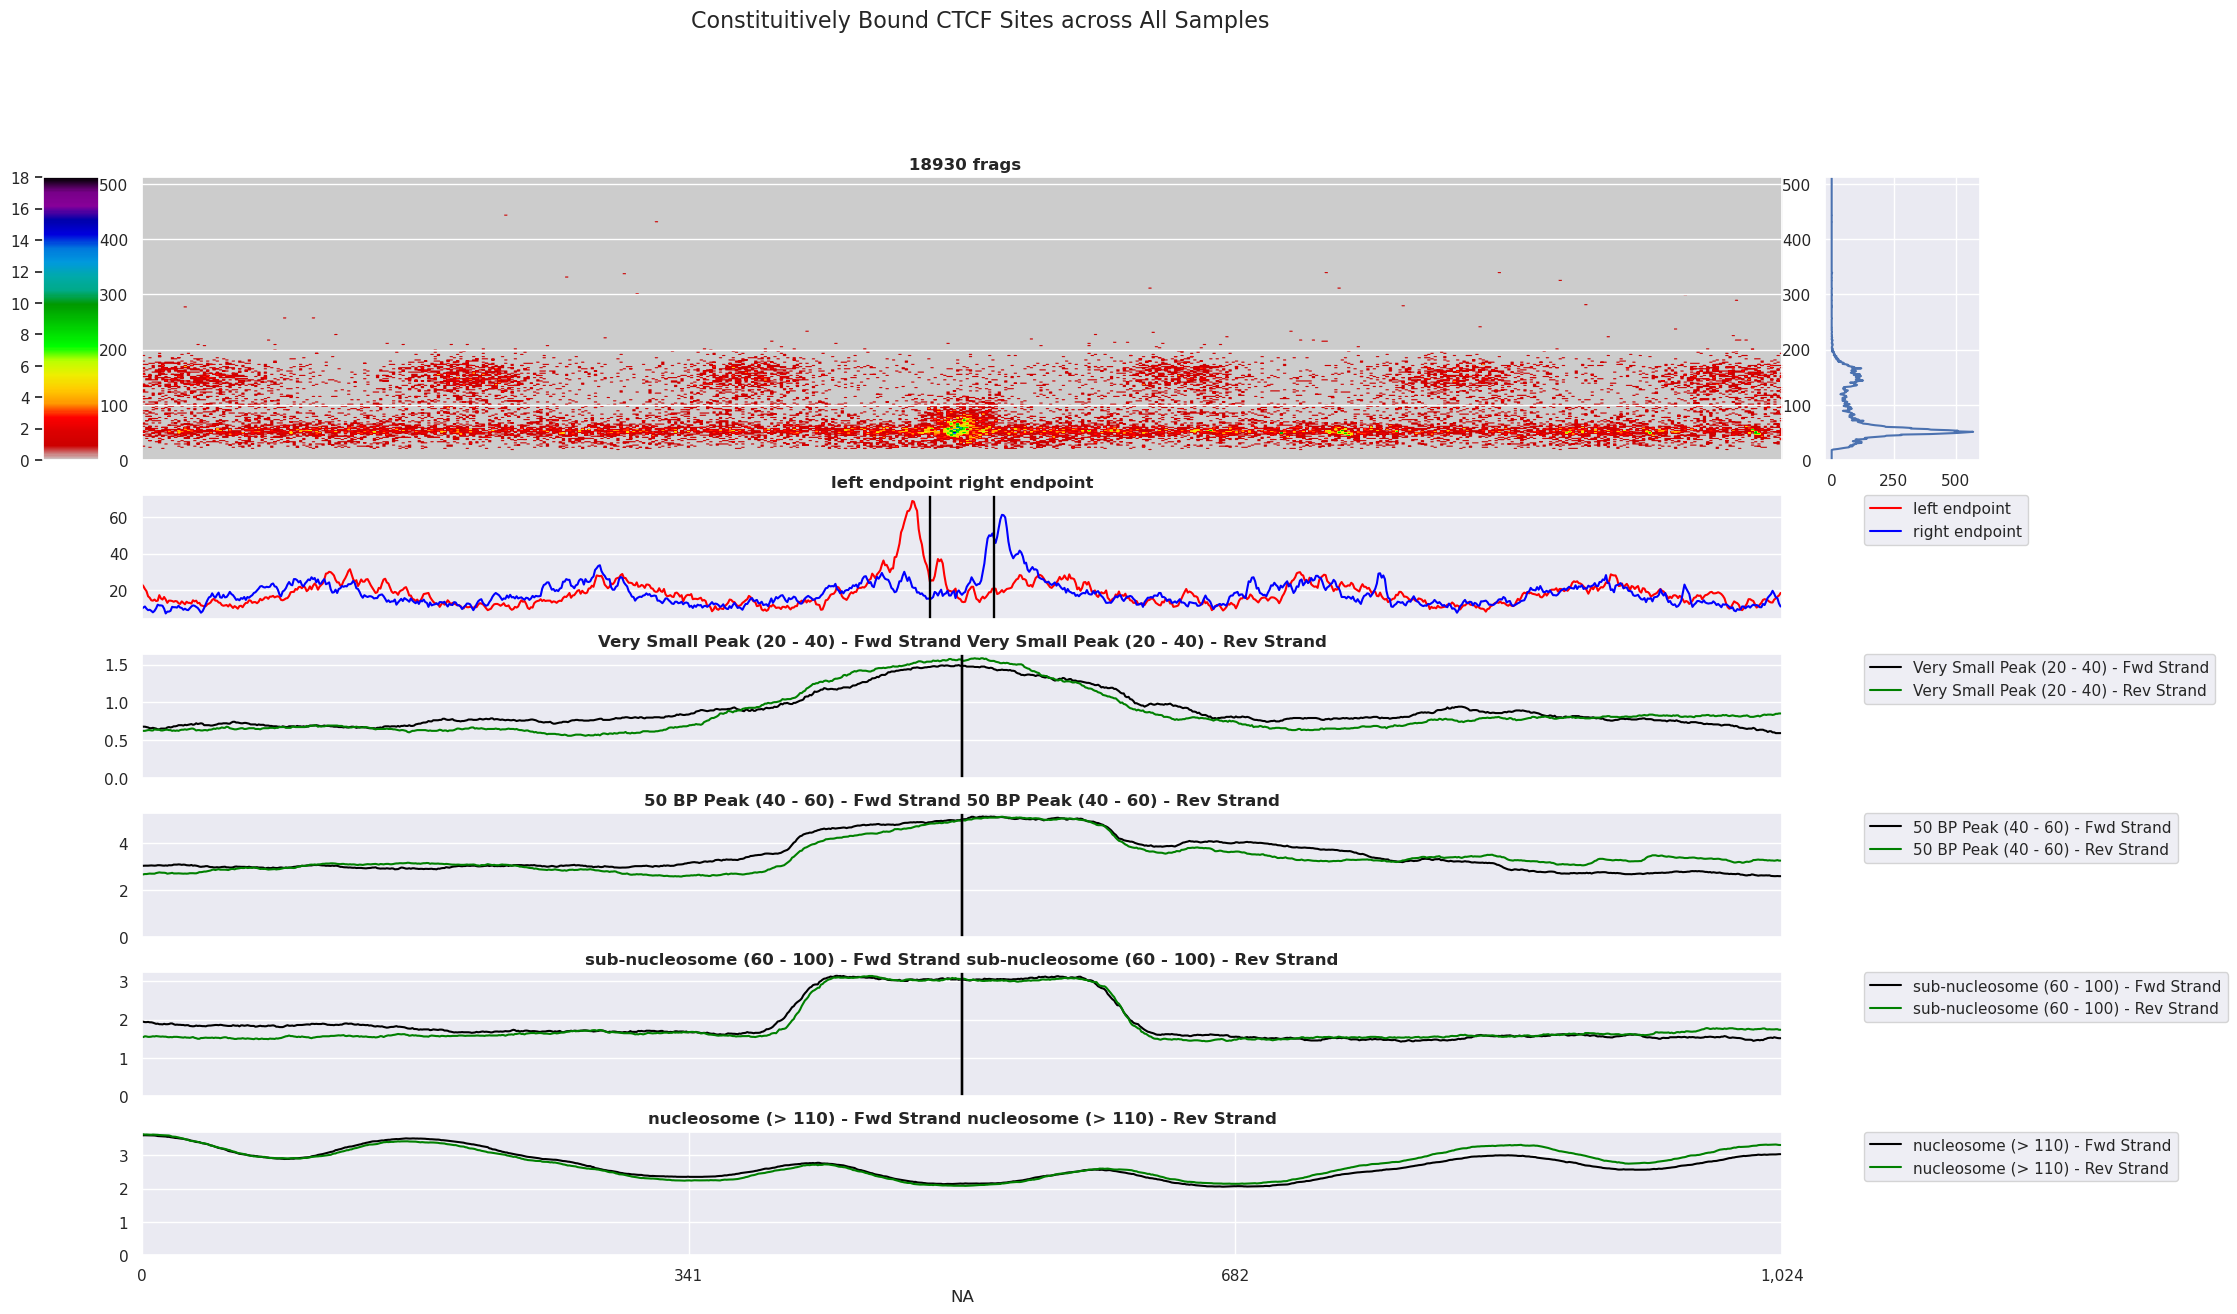

In [18]:
make_tracks(fa.resize(1024), True, True, True).plot(title='Constituitively Bound CTCF Sites across All Samples')

(<Figure size 2500x1400 with 8 Axes>,
 [<AxesSubplot:title={'center':' 293585 frags'}>,
  <AxesSubplot:title={'center':'left endpoint right endpoint'}>,
  <AxesSubplot:title={'center':'Very Small Peak (20 - 40) - Fwd Strand Very Small Peak (20 - 40) - Rev Strand'}>,
  <AxesSubplot:title={'center':'50 BP Peak (40 - 60) - Fwd Strand 50 BP Peak (40 - 60) - Rev Strand'}>,
  <AxesSubplot:title={'center':'sub-nucleosome (60 - 100) - Fwd Strand sub-nucleosome (60 - 100) - Rev Strand'}>,
  <AxesSubplot:title={'center':'nucleosome (> 110) - Fwd Strand nucleosome (> 110) - Rev Strand'}, xlabel='NA'>])

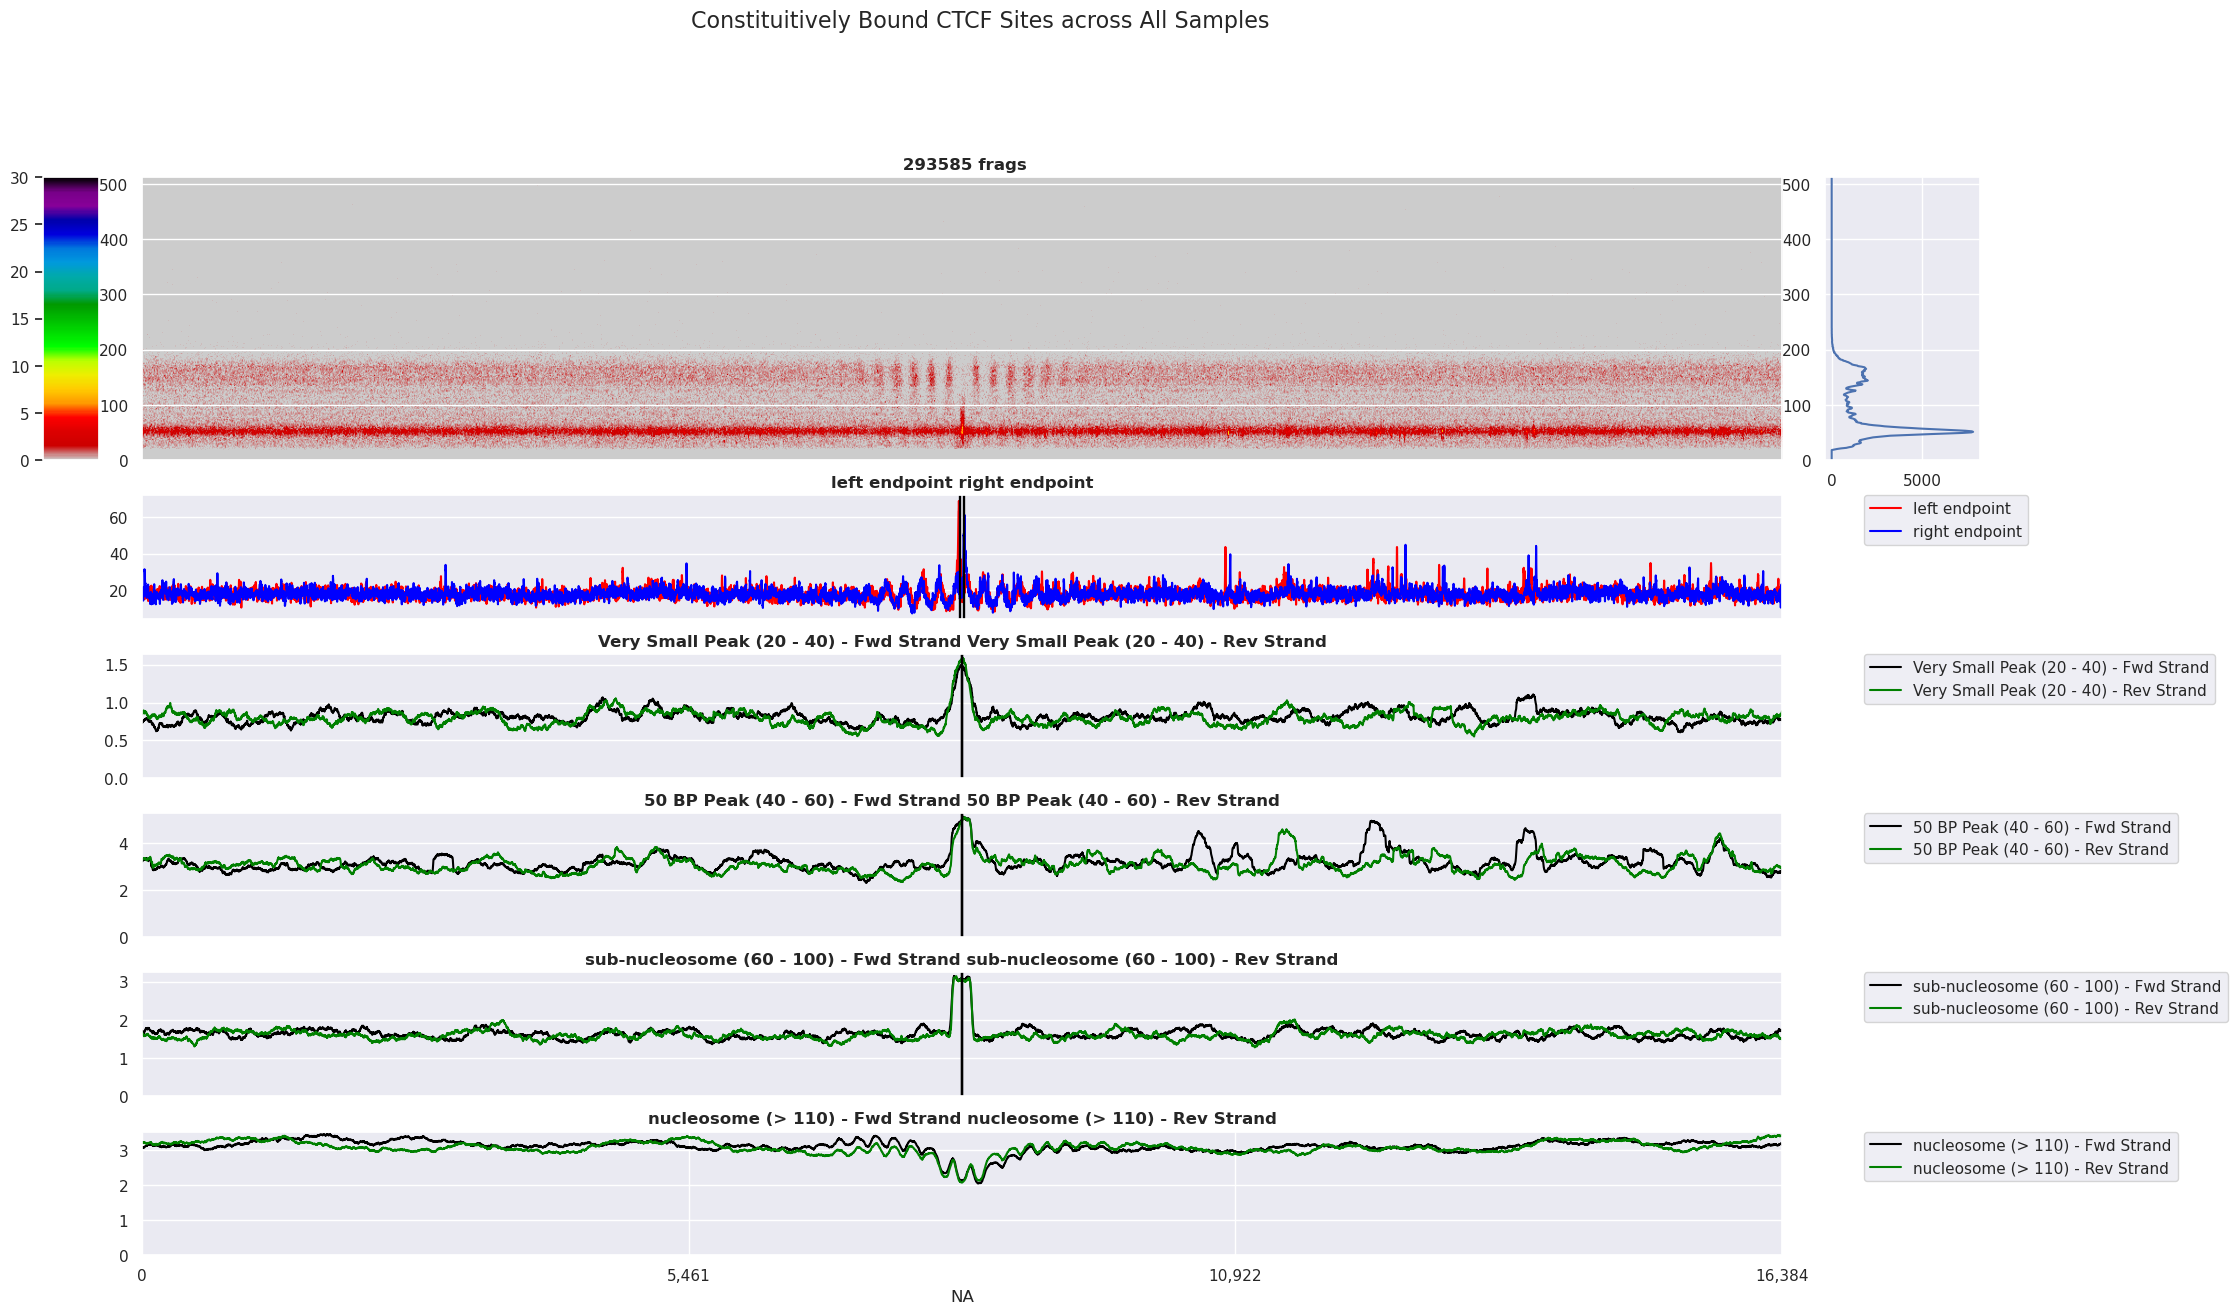

In [19]:
make_tracks(fa, True, True, True).plot(title='Constituitively Bound CTCF Sites across All Samples')

WARNING	2024-02-08 05:23:50,544	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:51,031	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:51,507	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:52,032	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:52,669	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:53,233	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:53,836	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:54,322	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:54,855	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:55,406	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:55,870	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:23:56,379	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-

WARNING	2024-02-08 05:24:23,764	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:24,214	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:24,663	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:25,127	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:25,581	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:26,048	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:26,533	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:27,171	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:27,648	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:28,111	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:28,572	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-08 05:24:29,047	Discarded 0 of 550 regions due to invalid resize.
WARNING	2024-02-

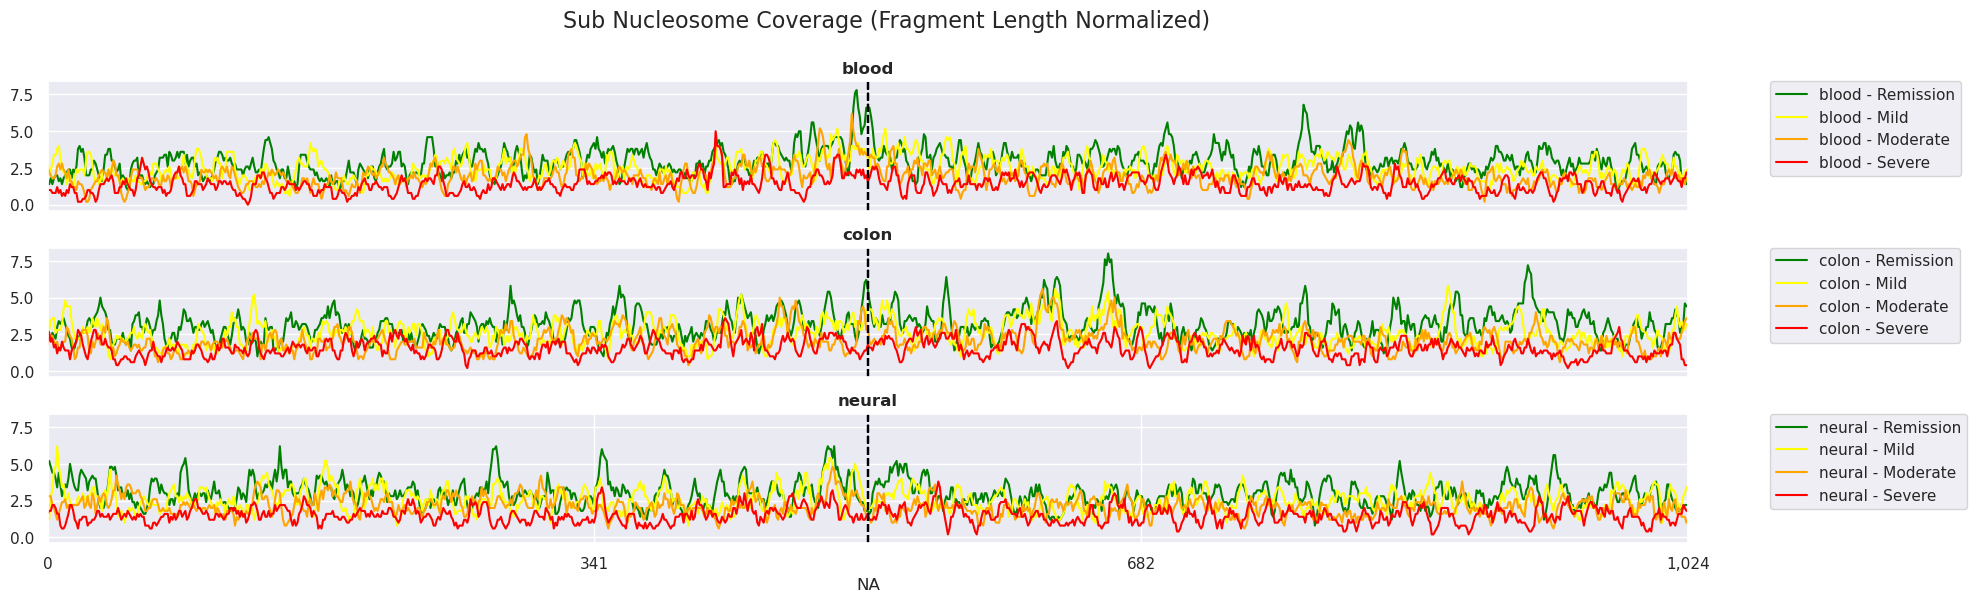

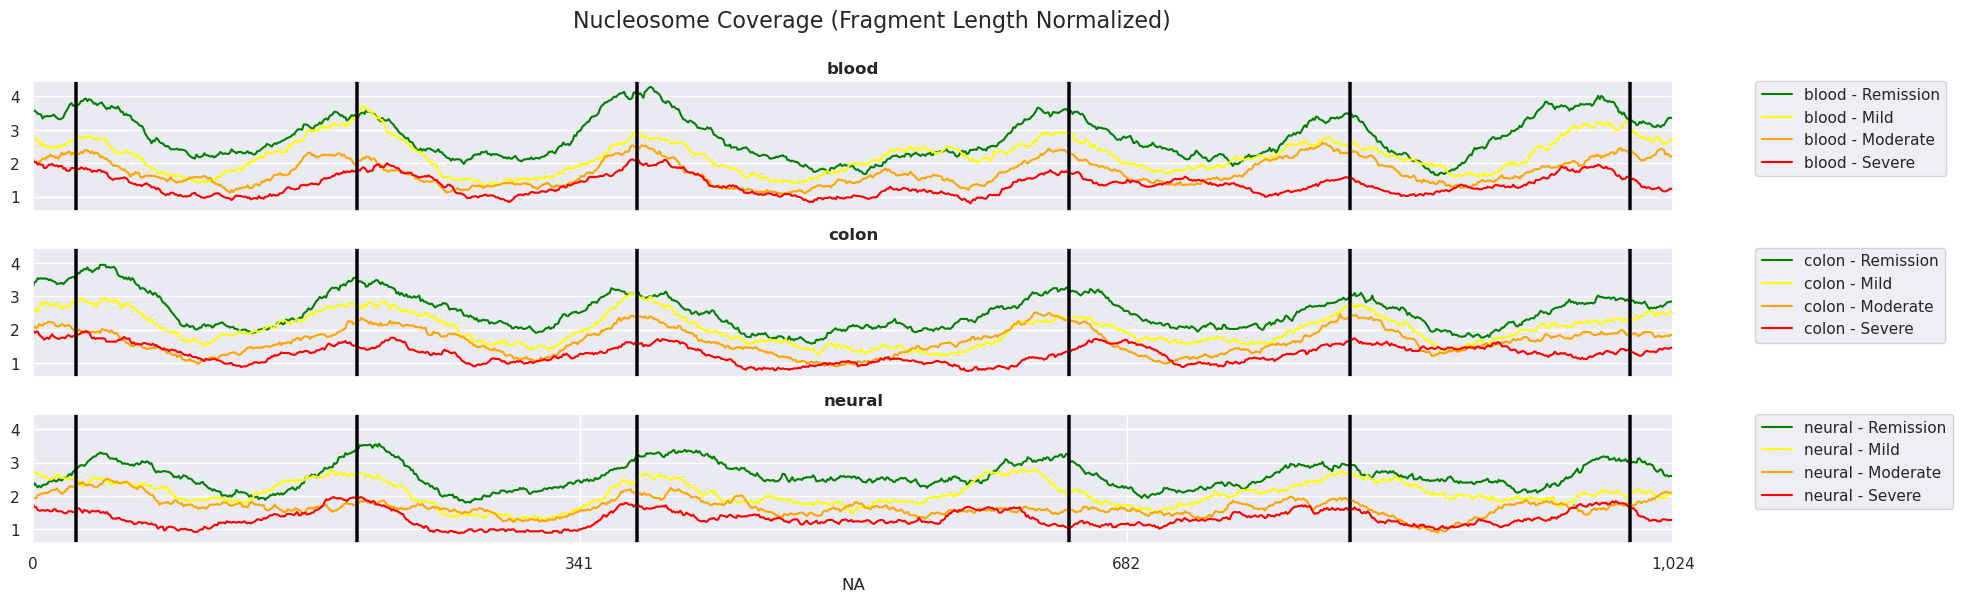

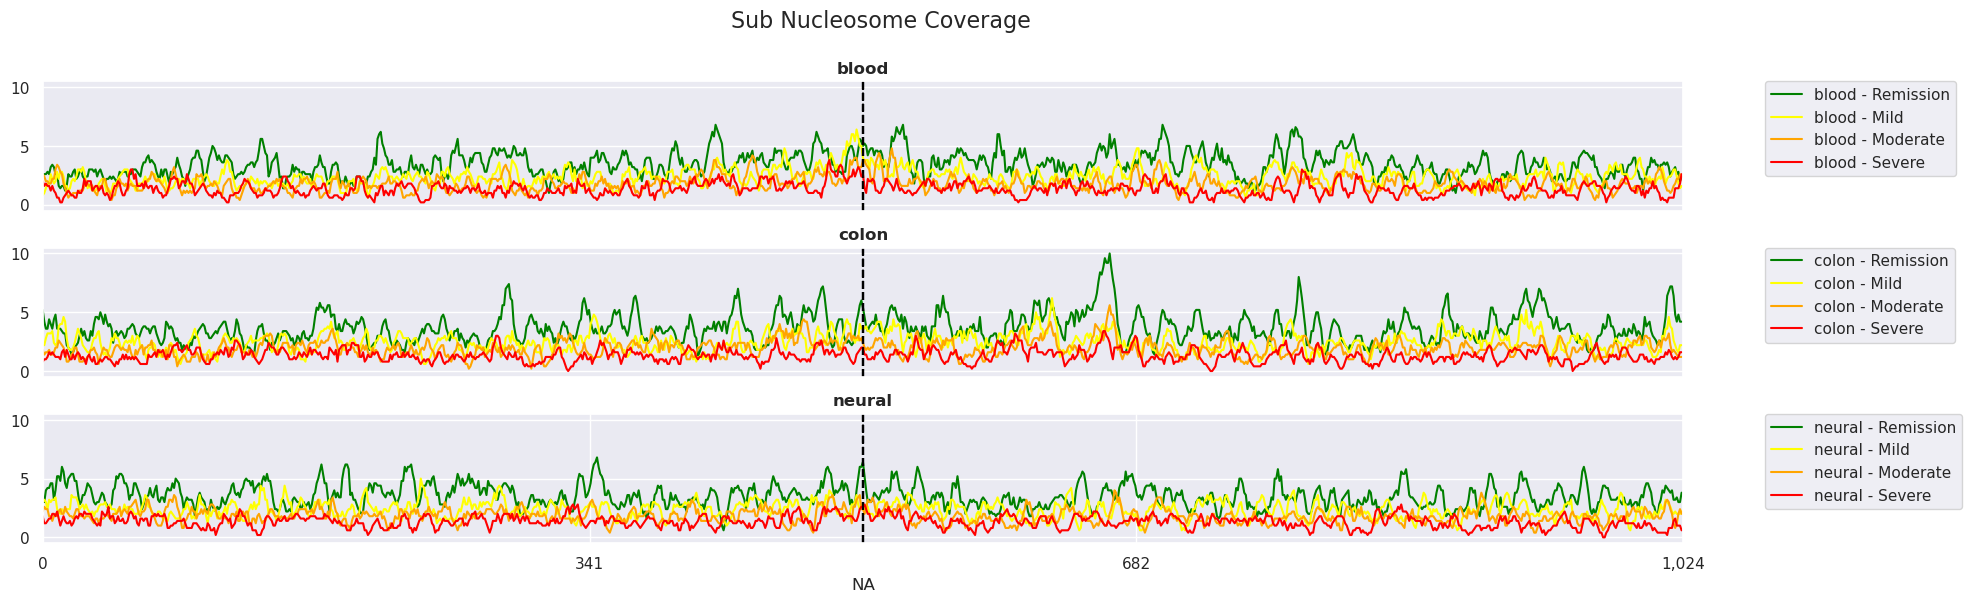

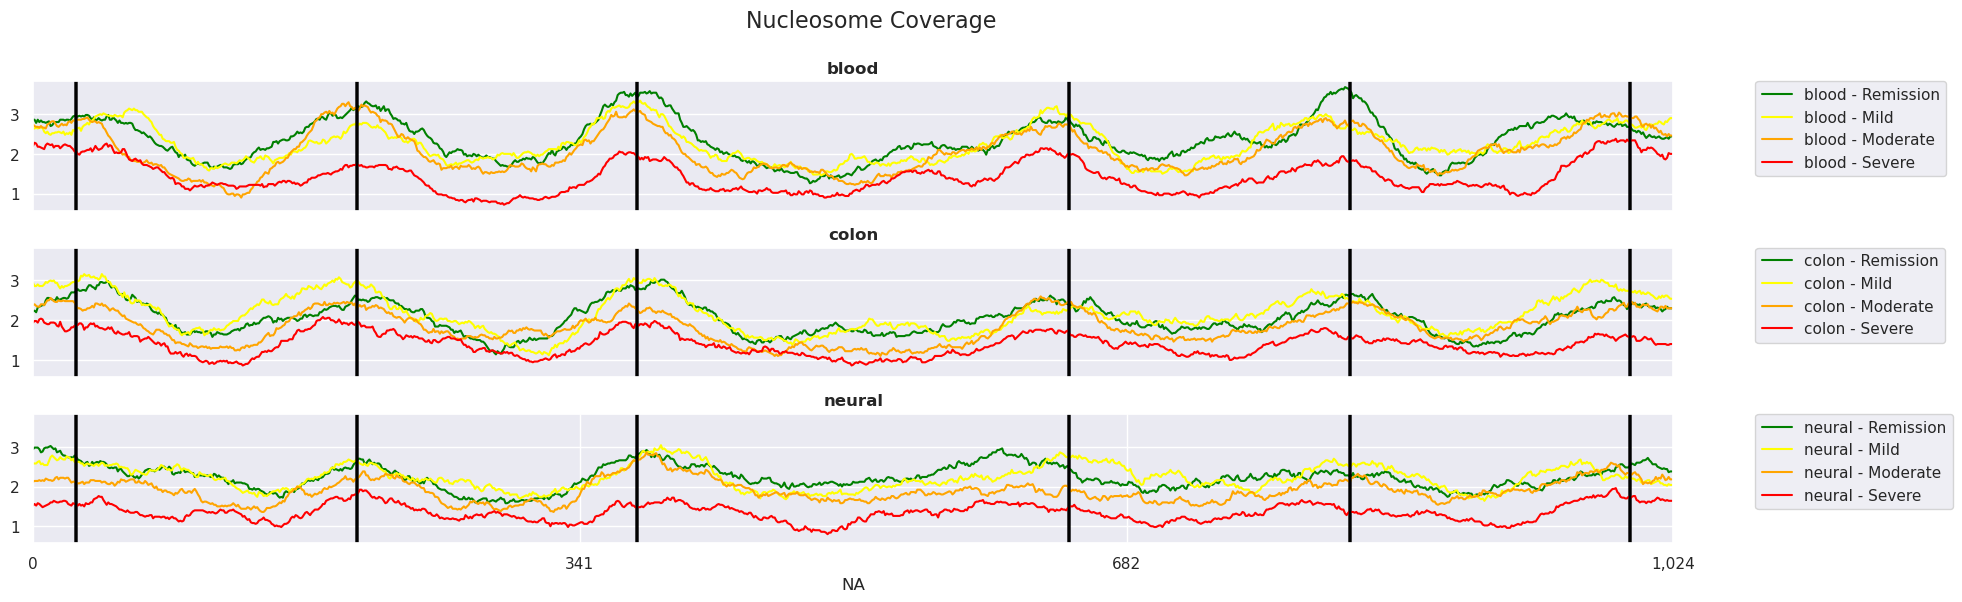

In [20]:
first_nuc=135
offset=175

for fl_normalize in [True, False]:
    all_sub_tracks = Tracks()
    all_nuc_tracks = Tracks()

    for cell_type_label in ['blood', 'colon', 'neural']: # , ,  'neural', 'all']:
        sub_nuc_tracks = []
        nuc_tracks = []
        for severity in severities:
            fa = fa_from_rdf_and_severity(severity, ctcf_rdf.query(f"cell_type == @cell_type_label"), region_size=1024, downsample_size=1500, fl_normalize=fl_normalize, max_num_samples=3)
            sub_nuc_tracks.append(
                CoverageTrack(fa, fa.plot_region, 
                              coverage_type='midpoint', fraction=(40, 60), smooth_window=5, 
                              n_boot_coverage=0,
                              ylim=(None, None),
                              vlines=[VLine(x=512, linestyle='dashed', alpha=0.2, linewidth=0.3)],
                              name=f'{cell_type_label} - {severity}',
                              color=color_mapping[severity],
                ))

            nuc_tracks.append(
                CoverageTrack(fa, fa.plot_region, 
                              coverage_type='midpoint', fraction=(110, 500), smooth_window=50, 
                              n_boot_coverage=0,
                              ylim=None, #  ylim=(2.5, 7.5),
                              vlines=[VLine(x=512+x) for x in (-first_nuc-2*offset, -first_nuc-offset, -first_nuc, first_nuc, first_nuc+offset, first_nuc+2*offset)], 
                              name=f'{cell_type_label} - {severity}',
                              color=color_mapping[severity],
                ))

        sub_nuc_track = sum(sub_nuc_tracks)
        sub_nuc_track.name = cell_type_label
        nuc_track = sum(nuc_tracks)
        nuc_track.name = cell_type_label

        all_sub_tracks.append(sub_nuc_track)
        all_nuc_tracks.append(nuc_track)

    all_sub_tracks.plot(title=f"Sub Nucleosome Coverage{' (Fragment Length Normalized)' if fl_normalize else ''}", sharey=True)
    all_nuc_tracks.plot(title=f"Nucleosome Coverage{' (Fragment Length Normalized)' if fl_normalize else ''}", sharey=True)

#make_tracks(fm_from_regions_mask_and_severity('Remission', only_blood_mask)) # .plot(title='Blood -- Remission')
#make_tracks(fm_from_regions_mask_and_severity('Mild', only_blood_mask)) # .plot(title='Blood -- Mild')
#make_tracks(fm_from_regions_mask_and_severity('Moderate', only_blood_mask)) # .plot(title='Blood -- Moderate')
#make_tracks(fm_from_regions_mask_and_severity('Severe', only_blood_mask)).plot(title='Blood -- Severe')

# TSS Sites

In [13]:
from ravel.constants import REPO_DIR
from ravel.bio.features import load_tss_s_df, load_gene_expression_df
from ravel.public_data_resources.roadmap import CELL_ANATOMY_TO_CELL_EID

In [14]:
tss_s = load_tss_s_df(ref='hg38')
tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301
1,chr1,169893923,169893924,ENSG00000000457.13_pk1,1000,-,ENSG00000000457,1,16.47,0.3748
2,chr1,169795042,169795043,ENSG00000000460.16_pk1,1000,+,ENSG00000000460,1,20.47,0.2621
3,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823
4,chr6,53545097,53545098,ENSG00000001084.10_pk1,1000,-,ENSG00000001084,1,17.27,0.9693
...,...,...,...,...,...,...,...,...,...,...
18272,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139
18273,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900
18274,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425
18275,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813


In [15]:
gene_expression = load_gene_expression_df(ref='hg38').set_index("ens_id")
gene_expression

,ENC1,ENC2,ENC3,ENC4,ENC5,ENC6,ENC7,ENC8,ENC9,ENC10,...,E114,E116,E117,E118,E119,E120,E122,E123,E127,E128
ens_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,47.45,26.19,0.31,0.18,3.41,1.25,5.71,3.87,2.74,4.16,...,37.989,0.038,42.639,49.983,11.554,11.847,43.723,0.267,13.758,15.818
ENSG00000000005,0.04,0.00,0.00,0.00,0.09,0.23,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.000,0.018,0.000,0.006,0.000,0.000
ENSG00000000419,179.87,154.74,24.58,20.34,4.21,1.64,16.48,13.09,12.21,8.39,...,52.215,79.197,107.098,62.811,42.386,54.869,16.652,73.719,56.578,56.371
ENSG00000000457,8.15,7.69,1.86,2.30,2.32,0.53,0.56,0.46,0.36,0.56,...,4.829,11.082,8.814,2.646,2.483,2.527,2.549,7.651,4.967,3.714
ENSG00000000460,26.32,18.98,1.22,1.18,0.92,0.32,3.59,2.61,1.82,3.41,...,8.001,13.743,25.369,3.373,4.646,2.179,4.099,22.103,3.290,2.491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000259667,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.032,0.000,0.000,0.000,0.006,0.000
ENSG00000259718,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
ENSG00000259741,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,74.923,22.036,23.527,16.770,25.595,57.260,15.039,8.164,31.558,57.093


In [16]:
from itertools import chain
gi_cell_eids = sorted(x for x in set(chain(*[CELL_ANATOMY_TO_CELL_EID[x] for x in ['gi_duodenum', 'gi_colon', 'gi_rectum', 'gi_stomach', 'gi_intestine', 'gi_esophagus']])) if x in gene_expression.columns)
blood_cell_eids = sorted(x for x in CELL_ANATOMY_TO_CELL_EID['blood'] if x in gene_expression.columns)

gi_cell_eids, blood_cell_eids

(['E079', 'E094', 'E106', 'E109'],
 ['E037', 'E038', 'E047', 'E050', 'E062', 'E116', 'E123'])

# TSS Analysis

In [17]:
def get_labeled_tss_s():
    filtered_tss_s = tss_s.query("num_tss_in_gene == 1").merge_gene_expression(gene_expression).copy()

    blood_labels = filtered_tss_s.set_binary_label_by_thresholds(
        blood_cell_eids[6],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('blood_label')

    gi_labels = filtered_tss_s.set_binary_label_by_thresholds(
        gi_cell_eids[:1],
        on_threshold=25,
        off_threshold=0.01,
        drop_unlabeled_records=False,
    )['label'].rename('gi_label')


    filtered_tss_s.loc[:, 'cell_type'] = None
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 1), 'cell_type'] = 'all'
    filtered_tss_s.loc[(gi_labels == 1) & (blood_labels == 0), 'cell_type'] = 'gi'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 1), 'cell_type'] = 'blood'
    filtered_tss_s.loc[(gi_labels == 0) & (blood_labels == 0), 'cell_type'] = 'none'

    filtered_tss_s['gene_id'] = filtered_tss_s.id.str.extract('(ENSG\d+)\..+')

    filtered_tss_s = filtered_tss_s.dropna().reset_index(drop=True)
    
    return filtered_tss_s

In [531]:
filtered_tss_s = get_labeled_tss_s()
filtered_tss_s.cell_type.value_counts()

[autoreload of ravel.fragment_array failed: Traceback (most recent call last):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 257, in check
    superreload(m, reload, self.old_objects)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 480, in superreload
    update_generic(old_obj, new_obj)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 329, in update_class
    if update_generic(old_obj, new_obj):
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", line 377, in update_generic
    update(a, b)
  File "/home/nboley/miniconda3/envs/ravel/lib/python3.9/site-packages/IPython/extensions/autoreload.py", li

none     1850
all       663
gi         61
blood       8
Name: cell_type, dtype: int64

In [19]:
filtered_tss_s, counts, fragment_stats = make_counts_and_region_stats(filtered_tss_s, sample_ids_to_samples)

  6%|██████████████████                                                                                                                                                                                                                                                                                                                    | 1/18 [00:06<01:42,  6.05s/it]


KeyboardInterrupt: 

In [ ]:
filtered_tss_s.cell_type.value_counts()

In [ ]:
# filtered_tss_s.query("cell_type == 'all'")
fa, fas = fa_from_rdf(filtered_tss_s.query("cell_type == 'all'"), FragmentsH5(sample_ids_to_samples['RD-56167']), region_size=4096, downsample_size=None, fl_normalize=False)

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'all'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Active TSS's over ALL IBD Samples")

In [ ]:
none_fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'none'"), region_size=4096*32, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(none_fa, True, True, True).plot(title="In-Active TSS's over ALL IBD Samples")

In [ ]:
fa = fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == 'blood'"), region_size=4096, fl_normalize=True, max_num_samples=12)

In [ ]:
make_tracks(fa, True, True, True).plot(title="Blood TSS's over ALL IBD Samples")

In [ ]:
list(filtered_tss_s.cell_type.unique())

In [ ]:
for cell_type in filtered_tss_s.cell_type.unique():
    make_tracks(fa_from_rdf_and_severity('ALL', filtered_tss_s.query("cell_type == @cell_type").sample(90), region_size=4096, fl_normalize=False, max_num_samples=12), extra_tracks=True).plot(title=f'TSS Expressed in {cell_type.upper()} across All Samples')

# Simulations

In [ ]:
RegionFragmentArray.from_fragments_h5("/scratch/test_samples/SEQRUN48_LIBRARY574.fragments.h5", Region.from_region_str("chr1:91419-91436").resize(1024))

In [ ]:
neg_density = fm_from_regions_mask(only_neural_mask).sum_pooled(1).dense_array.clip(1e-5)
neg_density = neg_density/neg_density.sum()

In [ ]:
pos_density = fm_from_regions_mask(only_blood_mask).sum_pooled(1).dense_array.clip(1e-5)
pos_density = pos_density/pos_density.sum()

In [ ]:
neg_density.ravel()

In [ ]:
from numpy.random import multinomial as sample_multinomial
from scipy.stats import multinomial as multinomal_density
def sample(p, n):
    x = sample_multinomial(n, p.ravel())
    x.resize(p.shape)
    return x

In [ ]:
n = 10000
disease_frac = 0.5
true = disease_frac*pos_density + (1-disease_frac)*neg_density
obs = sample(true, n)

multinomal_density.logpmf(obs.ravel(), obs.sum(), true.ravel())

In [ ]:
true.shape, obs.shape

In [ ]:
import numpy
numpy.random.rand(100)

# Gene Analysis

In [20]:
# use the gencode basic gtf to find all exonic regions 
# filter by: gene_type "protein_coding"
# find all genes by 
# merge all exons by gene
# take the gene end to be the first poly(A) tail (or the nearest end of the transcript)
# save into a region data frame, and attach fragment matrices
# build the coverage plots banded by fragment size
# stich these together, making sure that the fragment midpoint overlaps the exon
# make some plots!!!

In [416]:
%%time
gencode_df = pd.read_table(
    "/scratch/nboley/gencode/gencode.v39.basic.annotation.protein_coding.gff3",
    usecols=[0, 2, 3, 4, 6, 8],
    names=["contig", "element", "start", "stop", "strand", "meta"],
).query("contig not in ['chrM', 'chrY'] and element in ['transcript', 'exon', 'three_prime_UTR', 'five_prime_UTR']")
gencode_df['gene_id'] = gencode_df.meta.str.extract(';gene_id=(ENSG?\d+)\.\d+;')
gencode_df = gencode_df.drop(columns=['meta'])
gencode_df = gencode_df.drop_duplicates()
gencode_df = gencode_df.sort_values(["contig", "start"])

CPU times: user 8.86 s, sys: 376 ms, total: 9.23 s
Wall time: 9.24 s


In [417]:
gencode_df.element.value_counts()

exon               289650
five_prime_UTR      75701
transcript          58797
three_prime_UTR     54810
Name: element, dtype: int64

In [426]:
gencode_df.query("strand == '-'").head()

,contig,element,start,stop,strand,gene_id
13,chr1,transcript,450740,451678,-,ENSG00000284733
14,chr1,exon,450740,451678,-,ENSG00000284733
19,chr1,transcript,685716,686654,-,ENSG00000284662
20,chr1,exon,685716,686654,-,ENSG00000284662
125,chr1,transcript,944203,959256,-,ENSG00000188976


In [418]:
filtered_tss_s = get_labeled_tss_s() # [['gene_id', 'cell_type']]
filtered_tss_s

,contig,start,stop,id,score,strand,ens_id,num_tss_in_gene,pk_tpm,peakiness,...,E118,E119,E120,E122,E123,E127,E128,label,cell_type,gene_id
0,chr20,50958528,50958529,ENSG00000000419.12_pk1,1000,-,ENSG00000000419,1,121.79,0.7301,...,62.811,42.386,54.869,16.652,73.719,56.578,56.371,1,all,ENSG00000000419
1,chr1,196652051,196652052,ENSG00000000971.15_pk1,1000,+,ENSG00000000971,1,145.20,0.8823,...,0.007,0.419,39.724,8.464,41.504,1.348,32.725,1,all,ENSG00000000971
2,chr17,38870053,38870054,ENSG00000002834.17_pk1,1000,+,ENSG00000002834,1,317.87,0.8141,...,70.159,85.268,128.565,144.330,49.802,86.640,143.304,1,all,ENSG00000002834
3,chr7,127588432,127588433,ENSG00000004059.10_pk1,1000,+,ENSG00000004059,1,39.73,0.5661,...,81.860,198.680,89.048,230.688,108.866,124.927,65.374,1,all,ENSG00000004059
4,chr16,23596298,23596299,ENSG00000004779.9_pk1,1000,-,ENSG00000004779,1,88.24,0.4748,...,136.382,62.265,67.906,121.874,175.205,79.225,49.491,1,all,ENSG00000004779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2577,chr18,73473,73474,ENSG00000282965.1_pk1,1000,-,ENSG00000282965,1,4.53,0.3139,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000282965
2578,chr7,150405799,150405800,ENSG00000283013.1_pk1,1000,+,ENSG00000283013,1,1.53,0.1900,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283013
2579,chr4,119454625,119454626,ENSG00000283050.1_pk1,1000,-,ENSG00000283050,1,20.06,0.3425,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283050
2580,chr20,22685459,22685460,ENSG00000283072.1_pk1,1000,+,ENSG00000283072,1,2.86,0.5813,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0,none,ENSG00000283072


In [504]:
p_gene_starts_and_stops = filtered_tss_s.query("strand == '+'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'stop', 'strand', 'cell_type']].groupby(['gene_id']).min().rename(columns={'tss': 'start'})
p_gene_starts_and_stops['stop'] = p_gene_starts_and_stops['start'] + 1024*60
p_gene_starts_and_stops['start'] = p_gene_starts_and_stops['start'] - 4096


m_gene_starts_and_stops = filtered_tss_s.query("strand == '-'").set_index('gene_id')[['start', 'cell_type']].rename(columns={'start': 'tss'}).join(gencode_df.set_index('gene_id'), how='inner').query("element == 'transcript'")[['contig', 'tss', 'start', 'strand', 'cell_type']].groupby(['gene_id']).max().rename(columns={'tss': 'stop'})
m_gene_starts_and_stops['start'] = m_gene_starts_and_stops['stop'] - 1024*60
m_gene_starts_and_stops['stop'] = m_gene_starts_and_stops['stop'] + 4096


In [505]:
gene_starts_and_stops = pd.concat([p_gene_starts_and_stops, m_gene_starts_and_stops]).sort_values(['start', 'stop']).query('start > 0')
gene_starts_and_stops.cell_type.value_counts()

all      663
none     498
gi        61
blood      7
Name: cell_type, dtype: int64

In [506]:
#gene_starts = gencode_df.query("strand == '+' and element == 'five_prime_UTR'")[['gene_id', 'start']].groupby('gene_id').start.max() 
#gene_stops = gencode_df.query("strand == '+' and element == 'three_prime_UTR'")[['gene_id', 'stop']].groupby('gene_id').stop.min()
#gene_starts_and_stops = pd.DataFrame(gene_starts).join(gene_stops, how='inner')
#gene_starts_and_stops = gene_starts_and_stops.join(filtered_tss_s.set_index("gene_id"), how='inner')

In [507]:
?Region

Init signature:
Region(
    chrom: str,
    start: int = None,
    stop: int = None,
    strand: Optional[str] = None,
    ref: str = 'hg38',
    data: dict = None,
) -> None
Docstring:      Region(chrom: str, start: int = None, stop: int = None, strand: Optional[str] = None, ref: str = 'hg38', data: dict = None)
File:           ~/src/Ravel/fbio/region.py
Type:           type
Subclasses:     


In [508]:
%%time

def hstack_fas(fas):
    rv = fas[0]
    for fa in fas[1:]:
        rv = rv.hstack(fa)
    return rv

def get_fas(regions):
    # deal with positive strand
    # exon_grouper = gencode_df.query("strand == '+' and element == 'exon'")[['gene_id', 'contig', 'strand', 'start', 'stop']].groupby('gene_id')
    fas = {}
    for record in tqdm.tqdm(regions.itertuples(), total=regions.shape[0]):
        # gene_exons_df = RegionDataFrame(exon_grouper.get_group(record.Index).query("start >= @record.start and stop <= @record.stop"), ref='hg38')
        # if gene_exons_df.shape[0] == 0: continue
        inner_fas = []
        for frag_h5 in frag_h5s:
            inner_fas.append(RegionFragmentArray.from_fragments_h5(frag_h5, Region(record.contig, record.start, record.stop, record.strand), include_fragment_strand=True, flip_data_to_match_region_strand=True)) 
            # hstack_fas([RegionFragmentArray.from_fragments_h5(frag_h5, r, include_fragment_strand=True, flip_data_to_match_region_strand=True) for r in gene_exons_df.iter_regions()]))
        if len(inner_fas) > 0:
            fas[record.Index] = merge_fragment_arrays(inner_fas)

    return fas

CPU times: user 14 µs, sys: 2 µs, total: 16 µs
Wall time: 17.9 µs


In [509]:
fas = get_fas(gene_starts_and_stops)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1229/1229 [01:39<00:00, 12.40it/s]


In [510]:
df = gene_starts_and_stops.join(pd.Series(fas).rename('fa')).dropna()
df['fa_length'] = [fa.length for fa in df.fa.tolist()]
df['n_fragments'] = [fa.n_fragments for fa in df.fa.tolist()]

In [511]:
df['fa_length'].value_counts()

65536    1229
Name: fa_length, dtype: int64

<AxesSubplot:>

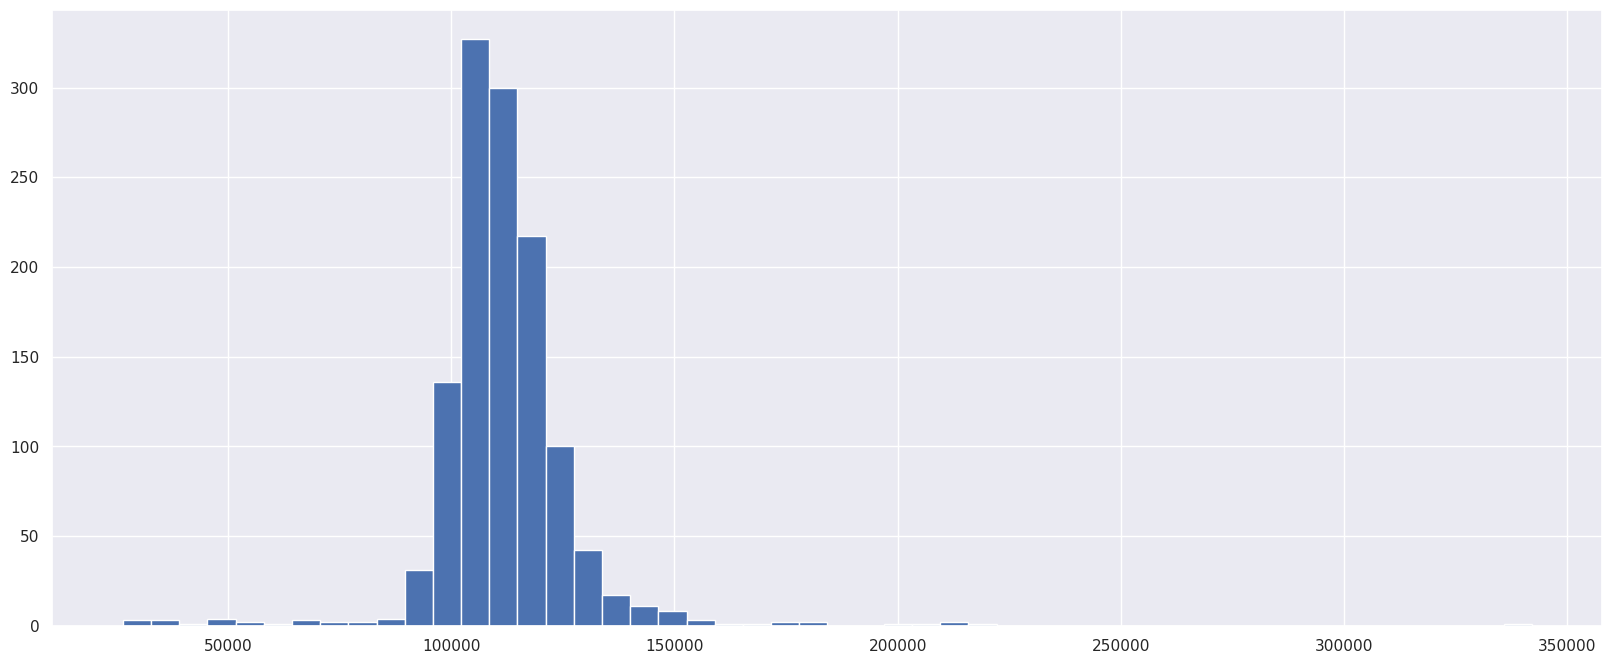

In [512]:
df['n_fragments'].hist(bins=50)

In [513]:
df

,contig,start,stop,strand,cell_type,fa,fa_length,n_fragments
gene_id,,,,,,,,
ENSG00000272602,chr4,49230,114766,+,none,"RegionFragmentArray(n_frags=142597, region=chr...",65536,142597
ENSG00000185627,chr11,232875,298411,+,all,"RegionFragmentArray(n_frags=125994, region=chr...",65536,125994
ENSG00000185885,chr11,309433,374969,+,all,"RegionFragmentArray(n_frags=146204, region=chr...",65536,146204
ENSG00000130731,chr16,574877,640413,-,all,"RegionFragmentArray(n_frags=113901, region=chr...",65536,113901
ENSG00000169020,chr4,612842,678378,-,all,"RegionFragmentArray(n_frags=211291, region=chr...",65536,211291
...,...,...,...,...,...,...,...,...
ENSG00000135902,chr2,232522104,232587640,+,none,"RegionFragmentArray(n_frags=118226, region=chr...",65536,118226
ENSG00000244474,chr2,233714693,233780229,+,gi,"RegionFragmentArray(n_frags=115849, region=chr...",65536,115849
ENSG00000182177,chr2,236202964,236268500,-,none,"RegionFragmentArray(n_frags=122924, region=chr...",65536,122924


In [514]:
import copy
from dataclasses import dataclass, field, replace
from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

# frag_h5 = FragmentsH5("/scratch/karius/finished.fragments.h5") # "/scratch/test_samples/SEQRUN48_LIBRARY577.fragments.h5")
patient_groups = ['Patient Group  1', 'Patient Group  2']
patient_groups = metadata.Cluster.unique().tolist()

severities = ('Remission', 'Mild', 'Moderate', 'Severe')

from fbio.plot.tracks import CoverageTrack, VLine, Tracks, VplotTrack

@dataclass
class CoverageDifferenceTrack(CoverageTrack):
    def _build_coverage(self, *args, **kwargs):
        c1 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('+').get_midpoint_coverage_array() 
        c2 = copy.deepcopy(self.data).subset_fragment_lengths(self.fraction[0], self.fraction[1]).subset_by_fragment_strand('-').get_midpoint_coverage_array() 
        return c2 - c1

    def _plot(self, ax): 
        super()._plot(ax)
        ax.axhline(0)

def StrandSplitCoverageTrack(fa, *args, **kwargs):
    p1 = CoverageTrack(fa.subset_by_fragment_strand('+'), *args, color='black', **kwargs)
    p1.name = p1.name + ' - Fwd Strand'
    p2 = CoverageTrack(fa.subset_by_fragment_strand('-'), *args, color='green', **kwargs)
    p2.name = p2.name + ' - Rev Strand'
    return p1 + p2

def make_single_strand_tss_tracks(fa, include_vplot=False):
    region_size = fa.shape[1]

    region_size//2+145
    first_nuc=132
    offset=175
    tracks = Tracks()
    if include_vplot:
        tracks.append(VplotTrack(fa, fa.plot_region, sum_pool_by=2))

    for fraction, sm_win in [((40, 60), 300), ((60, 100), 700), ((110, 500), 1500)]:
        for TrackCls in (StrandSplitCoverageTrack, CoverageDifferenceTrack):
            tracks.append(TrackCls(fa, fa.plot_region, coverage_type='midpoint', n_boot_coverage=0, fraction=fraction, smooth_window=sm_win, ylim=(None, None),
                                    vlines=[VLine(x=4096)], 
                                    name=f'{fraction[0]} - {fraction[1]} bp Fraction)'))
    return tracks

In [523]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'all' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39948861 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

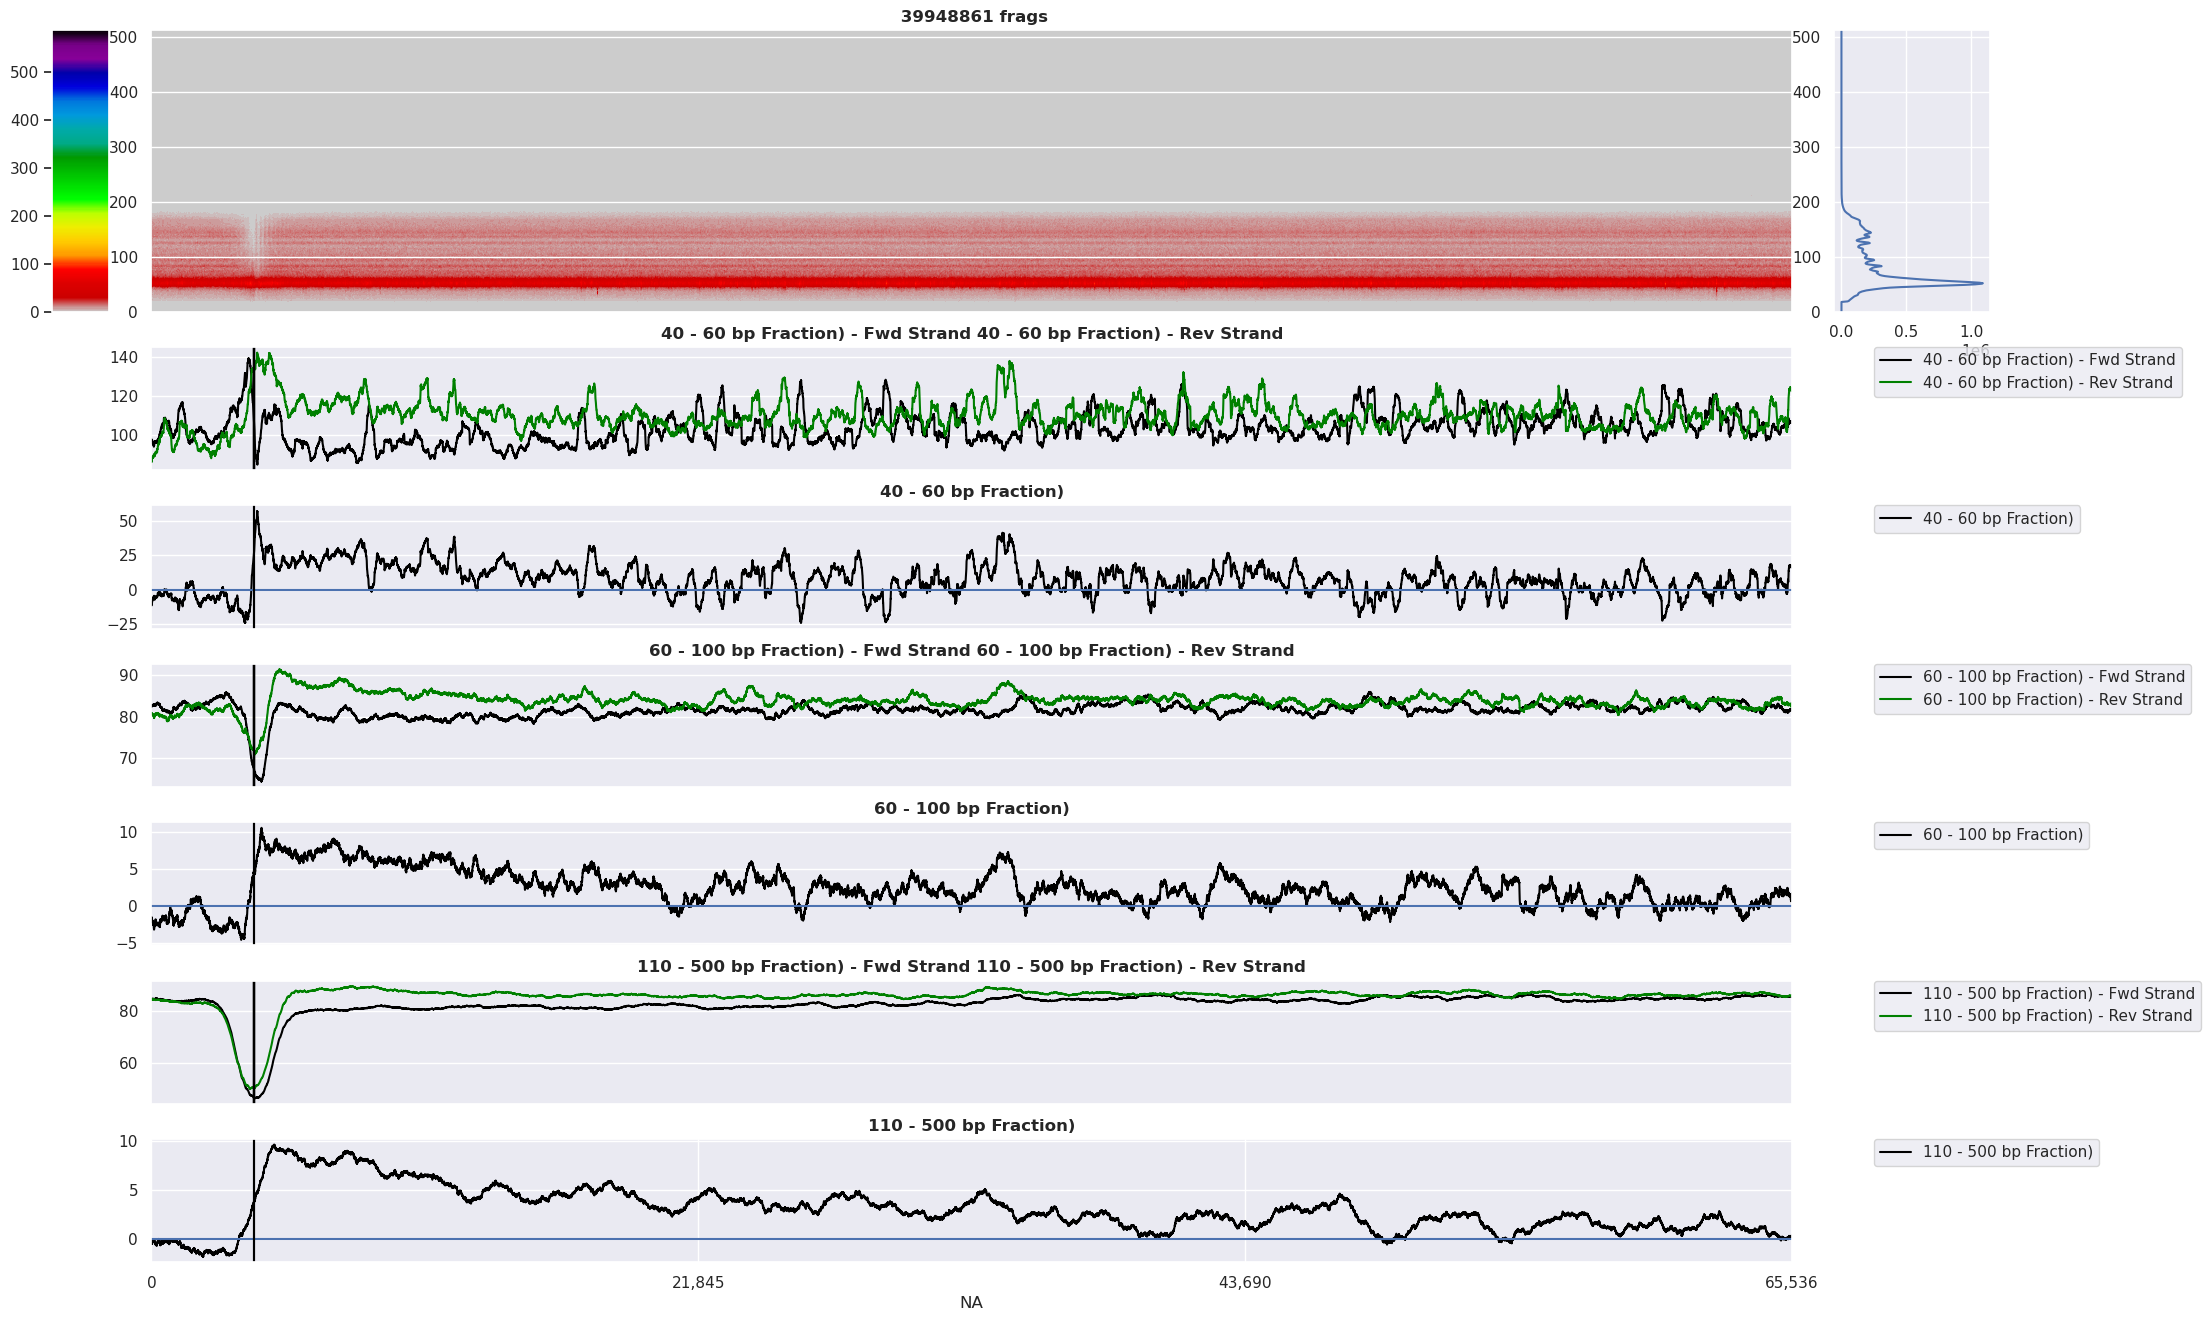

In [524]:
make_single_strand_tss_tracks(fa, True).plot()

(<Figure size 2500x1600 with 9 Axes>,
 [<AxesSubplot:title={'center':' 39951221 frags'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction) - Fwd Strand 40 - 60 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'40 - 60 bp Fraction)'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction) - Fwd Strand 60 - 100 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'60 - 100 bp Fraction)'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction) - Fwd Strand 110 - 500 bp Fraction) - Rev Strand'}>,
  <AxesSubplot:title={'center':'110 - 500 bp Fraction)'}, xlabel='NA'>])

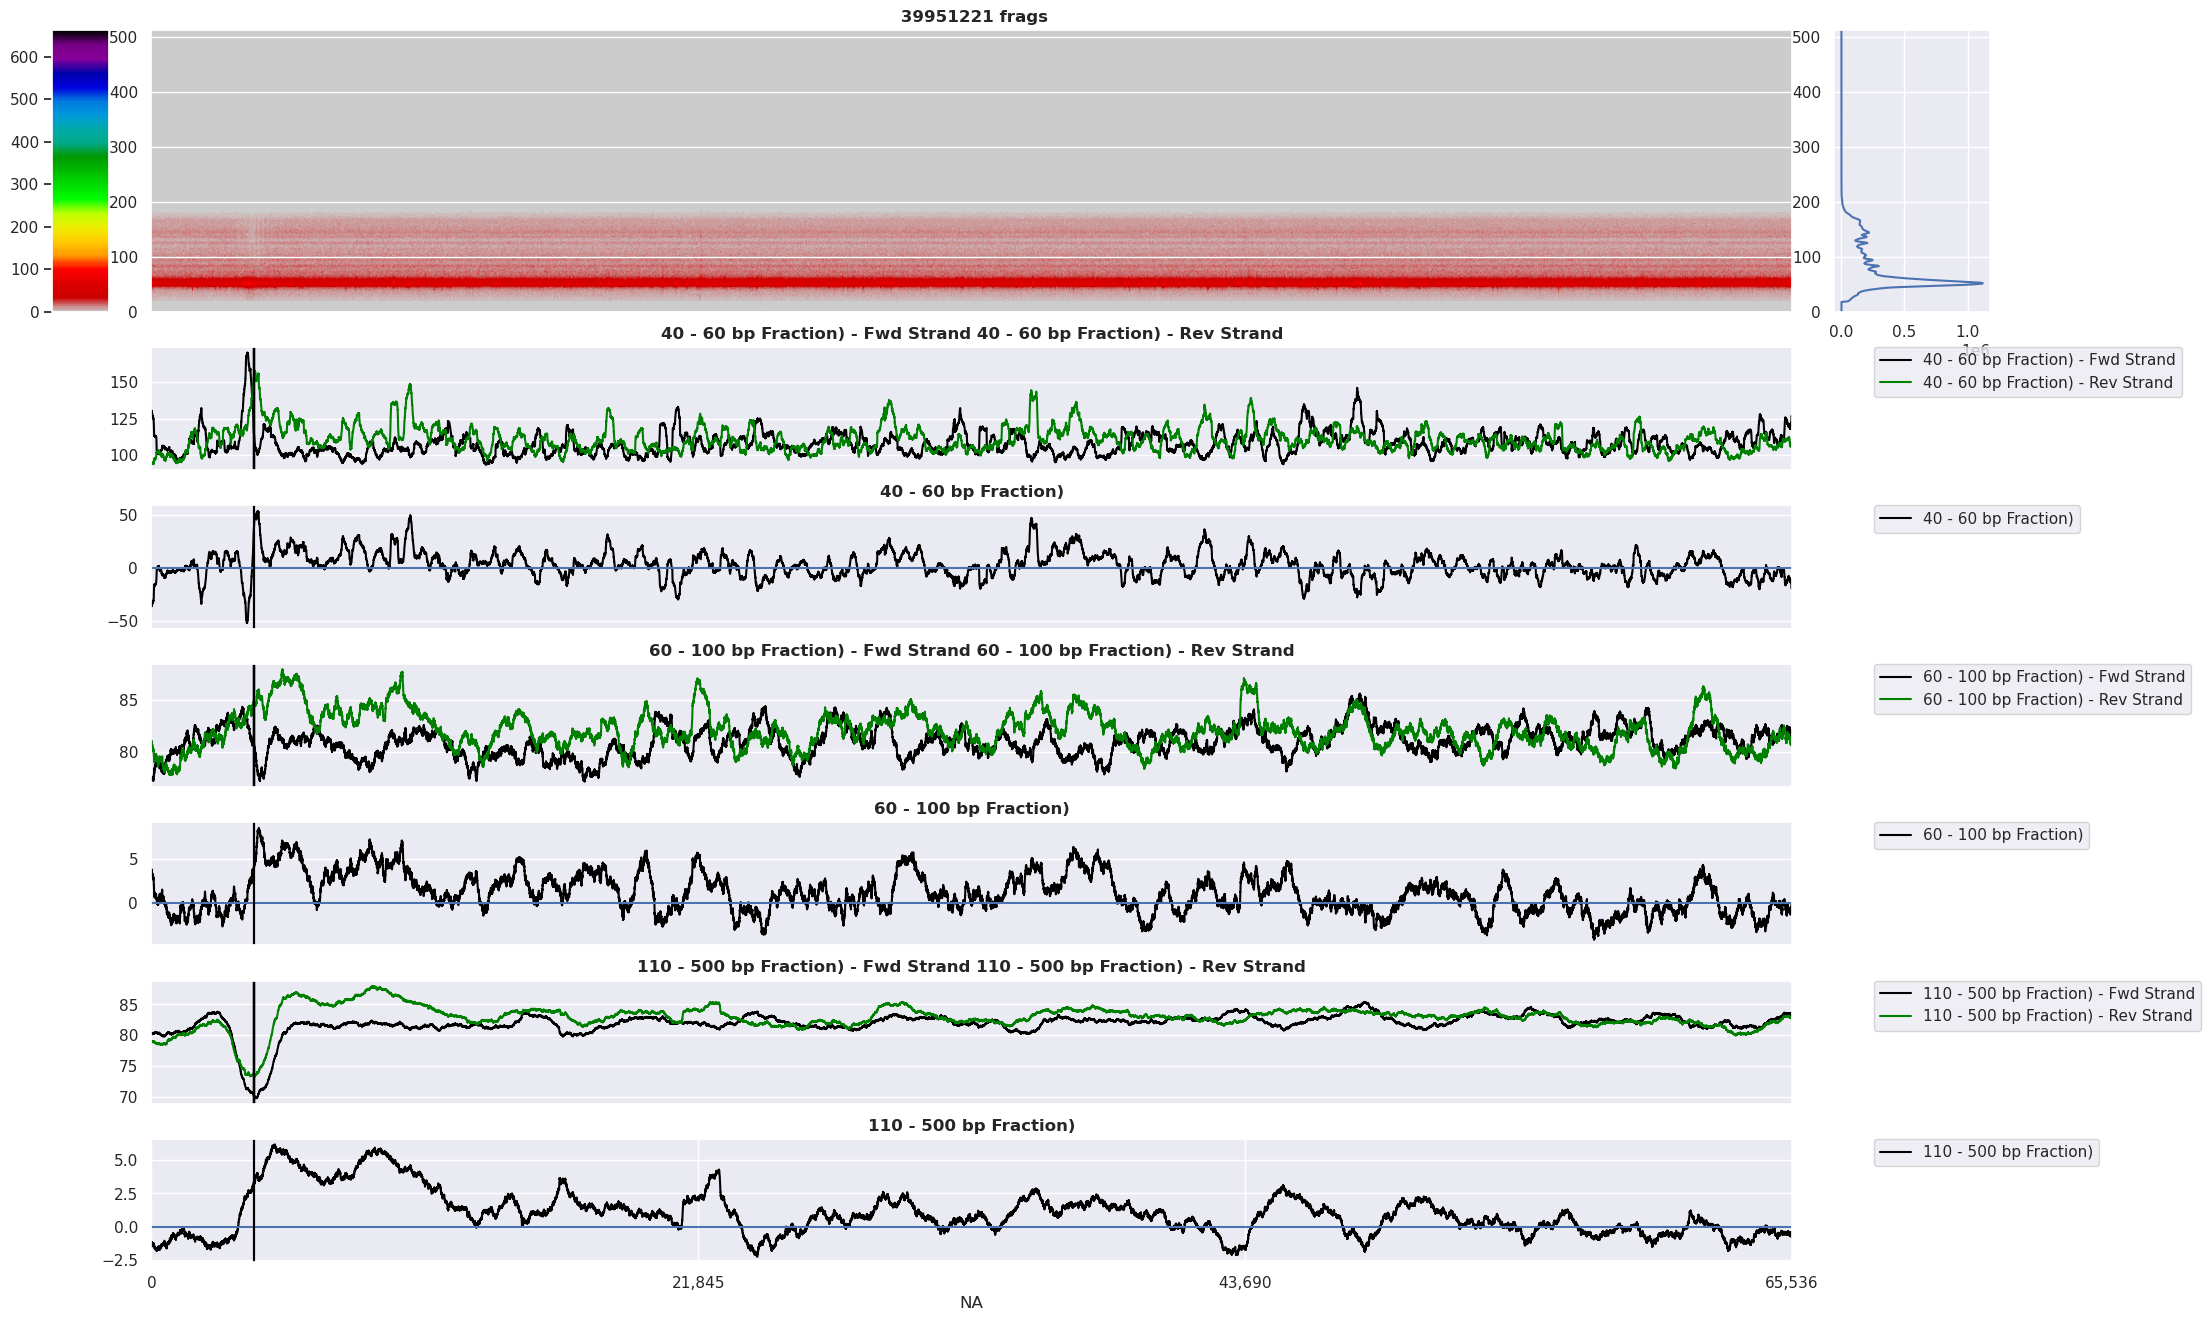

In [525]:
fa = merge_fragment_arrays([_ for _ in df.query("cell_type == 'none' and n_fragments > 100000 and n_fragments < 130000").fa.tolist()]).downsampled(40000000) # cell_type == 'all' and 
make_single_strand_tss_tracks(fa, True).plot()

In [181]:
pd.DataFrame([.truncate(1024)fm.length for fm in fms]).hist(bins=100)

SyntaxError: invalid syntax (1376398094.py, line 1)

(<Figure size 2500x200 with 1 Axes>,
 [<AxesSubplot:title={'center':'coverage'}, xlabel='NA'>])

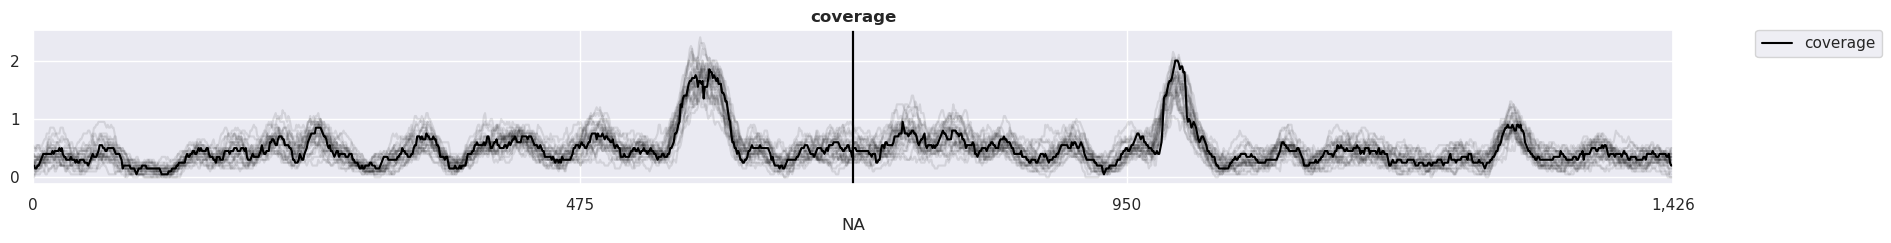

In [423]:
import scipy
tracks = fms[100].make_tracks()
del tracks[0]
tracks.plot()

In [282]:
df.query("strand == '+' and element == 'exon'")

,start,stop
gene_id,,
ENSG00000000005,"[100584936, 100585231, 100593895, 100594261, 1...","[100585066, 100585362, 100594035, 100594362, 1..."
ENSG00000000460,"[169794730, 169795040, 169795043, 169795409, 1...","[169794905, 169795115, 169795213, 169795983, 1..."
ENSG00000000971,"[196652043, 196652045, 196652056, 196672978, 1...","[196652175, 196652175, 196652175, 196673163, 1..."
ENSG00000001167,"[41072974, 41072983, 41079029, 41079029, 41080...","[41073084, 41073084, 41079164, 41079164, 41080..."
ENSG00000001461,"[24415802, 24415803, 24415813, 24415814, 24419...","[24415904, 24415904, 24415904, 24415904, 24419..."
...,...,...
ENSG00000289282,"[31623874, 31624261, 31624450, 31625171, 31625...","[31623909, 31624360, 31624522, 31625314, 31625..."
ENSG00000289325,[66926308],[66926346]
ENSG00000289360,[105040848],[105040925]


In [270]:
df.query("gene_id == 'ENSG00000289281'")

,contig,element,start,stop,strand,gene_id
1228392,chr16,exon,3004132,3004601,+,ENSG00000289281
1228398,chr16,five_prime_UTR,3004132,3004240,+,ENSG00000289281
1228395,chr16,exon,3004603,3004859,+,ENSG00000289281
